### **Mini-projet : Analyse prédictive du risque de maladie cardiaque**

Ce projet couvre toute la chaîne de traitement en Machine Learning, depuis l’exploration du dataset jusqu’au déploiement d’un modèle prédictif.

**Objectifs :**

- Préparer les données avec des pipelines pour les variables numériques et catégorielles

- Utiliser un ColumnTransformer pour combiner les transformations

- Construire un pipeline complet intégrant prétraitement → ACP → modèle supervisé

- Optimiser les hyperparamètres avec GridSearchCV

- Sélectionner le meilleur modèle et le sauvegarder sous .pkl

- Développer une mini-application Streamlit pour la prédiction

## **1️⃣ Chargement et exploration du dataset**

### Chargement du dataset

Le fichier `CHD.csv` contient des données médicales permettant de prédire le risque de maladie cardiaque.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    'CHD.csv',
    skipinitialspace=True,  # Supprime les espaces après les délimiteurs
    na_values=['', ' ', 'NA', 'NaN', 'null']  # Définit ce qui est considéré comme NA
)

In [2]:
#visualisation des 5 premieres valeurs 
df.head()

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
0,160.0,12.0,573.0,2311.0,Present,49.0,253.0,972.0,52.0,1
1,144.0,NaN,441.0,2861.0,Absent,55.0,2887.0,206.0,63.0,1
2,118.0,NaN,348.0,3228.0,Present,52.0,2914.0,381.0,46.0,0
3,170.0,NaN,641.0,3803.0,Present,51.0,3199.0,2426.0,58.0,1
4,134.0,NaN,35.0,2778.0,Present,60.0,2599.0,5734.0,49.0,1


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sbp        462 non-null    float64
 1   tobacco    165 non-null    float64
 2   ldl        461 non-null    float64
 3   adiposity  462 non-null    float64
 4   famhist    462 non-null    object 
 5   typea      462 non-null    float64
 6   obesity    462 non-null    float64
 7   alcohol    440 non-null    float64
 8   age        462 non-null    float64
 9   chd        462 non-null    int64  
dtypes: float64(8), int64(1), object(1)
memory usage: 36.2+ KB


In [4]:
df.describe()


,sbp,tobacco,ldl,adiposity,typea,obesity,alcohol,age,chd
count,462.000000,165.000000,461.000000,462.000000,462.000000,462.000000,440.000000,462.000000,462.000000
mean,138.326840,2.442424,440.488069,2325.296537,53.103896,2375.183983,1435.856818,42.816017,0.346320
std,20.496317,4.396994,236.753611,1012.515632,9.817534,818.954523,2208.468438,14.608956,0.476313
min,101.000000,0.000000,4.000000,12.000000,13.000000,20.000000,0.000000,15.000000,0.000000
25%,124.000000,0.000000,299.000000,1721.250000,47.000000,2208.250000,13.500000,31.000000,0.000000
50%,134.000000,0.000000,417.000000,2540.500000,53.000000,2526.500000,442.500000,45.000000,0.000000
75%,148.000000,3.000000,563.000000,3074.750000,60.000000,2807.750000,1951.750000,55.000000,1.000000
max,218.000000,20.000000,1533.000000,4249.000000,78.000000,4658.000000,14719.000000,64.000000,1.000000


In [5]:
#Afficher les diemsions de la BDD
df.shape

(462, 10)

In [6]:
#Afficher les types de variables
print(df.dtypes)

sbp          float64
tobacco      float64
ldl          float64
adiposity    float64
famhist       object
typea        float64
obesity      float64
alcohol      float64
age          float64
chd            int64
dtype: object


In [7]:
df["famhist"].value_counts() 


famhist
Absent     270
Present    192
Name: count, dtype: int64

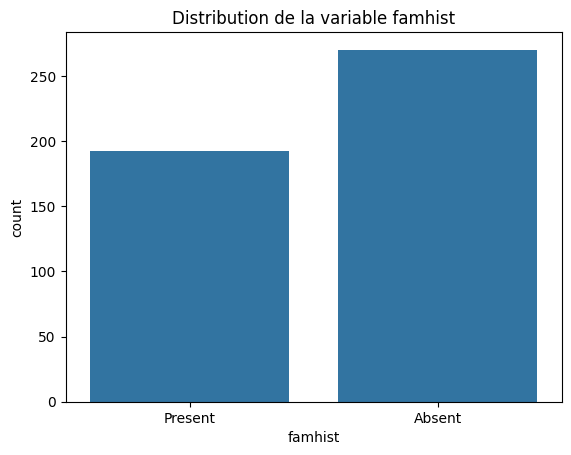

In [8]:
sns.countplot(x='famhist', data=df)
plt.title("Distribution de la variable famhist")
plt.show()

On observe une distribution inégale de la variable famhist, caractérisée par une présence nettement plus importante de la modalité absent par rapport à la modalité présent.

sbp            0
tobacco      297
ldl            1
adiposity      0
famhist        0
typea          0
obesity        0
alcohol       22
age            0
chd            0
dtype: int64


<Axes: >

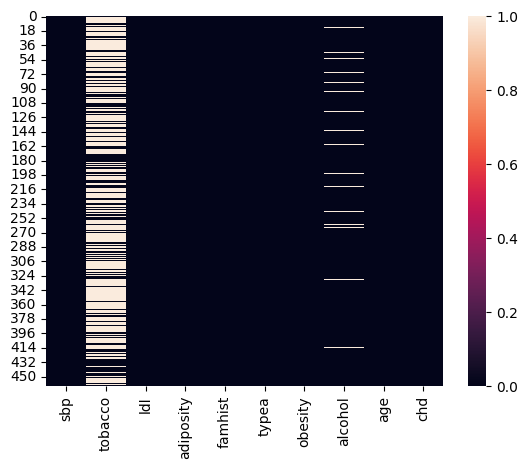

In [9]:
#Identifier les données manquantes
print(df.isnull().sum())
# Représenter les données manquantes
sns.heatmap(df.isnull())

`interpretation:` aucune valeur manquantes 

## **2️⃣ ÉTAPE 2 — Séparation du dataset**

In [10]:
X = df.drop("chd", axis=1)# Variables explicatives 
y = df["chd"]# Variable cible
X = X.replace(" ", np.nan)#remplacer les vides 


- **X** : variables explicatives
- **y** : variable cible (`chd`)

Les données sont divisées en :
- 67 % apprentissage
- 33 % test
- Stratification sur `chd`

In [11]:
print(X.head)

<bound method NDFrame.head of        sbp  tobacco     ldl  adiposity  famhist  typea  obesity  alcohol   age
0    160.0     12.0   573.0     2311.0  Present   49.0    253.0    972.0  52.0
1    144.0      NaN   441.0     2861.0   Absent   55.0   2887.0    206.0  63.0
2    118.0      NaN   348.0     3228.0  Present   52.0   2914.0    381.0  46.0
3    170.0      NaN   641.0     3803.0  Present   51.0   3199.0   2426.0  58.0
4    134.0      NaN    35.0     2778.0  Present   60.0   2599.0   5734.0  49.0
..     ...      ...     ...        ...      ...    ...      ...      ...   ...
457  214.0      NaN   598.0     3172.0   Absent   64.0   2845.0      0.0  58.0
458  182.0      NaN   441.0      321.0   Absent   52.0   2861.0   1872.0  52.0
459  108.0      3.0   159.0     1523.0   Absent   40.0   2009.0   2664.0  55.0
460  118.0      NaN  1161.0     3079.0   Absent   64.0   2735.0   2397.0  40.0
461  132.0      0.0   482.0     3341.0  Present   62.0    147.0      0.0  46.0

[462 rows x 9 columns

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.33,
    random_state=123,
    stratify=y
)


🧠 Explication ligne par ligne
🔹 test_size=0.33

👉 33 % des données pour tester le modèle
   👉 67 % pour l’entraînement

🔹 random_state=123

👉 Garantit que :

    les résultats sont reproductibles

🔹 stratify=y (TRÈS IMPORTANT)

👉 Assure que :

  la proportion de chd=0 et chd=1

  est la même dans train et test

  Sans ça ➜ risque de jeu de test biaisé ❌

 ## **3️⃣ Prétraitement des variables numériques**

numériques
🎯 Objectif de cette étape

- Préparer les variables numériques pour le modèle en :

- gérer les valeurs manquantes (imputation)

- mettant toutes les variables à la même échelle (standardisation)



Identifier les variables numériques

In [13]:

num_features = X.select_dtypes(include=["int64", "float64"]).columns
num_features


Index(['sbp', 'tobacco', 'ldl', 'adiposity', 'typea', 'obesity', 'alcohol',
       'age'],
      dtype='object')

Construire le pipeline numérique

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])


Étapes :
1. **Imputation (mean)** : remplacement des valeurs manquantes
2. **Standardisation** : mise à l’échelle des variables

**Interprétation :**
> La standardisation est essentielle pour l’ACP et les modèles basés sur la distance.

## 4️⃣ Prétraitement de la variable catégorielle `famhist`


In [15]:

cat_features = ["famhist"]

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder


from sklearn.base import BaseEstimator, TransformerMixin

class FamhistCleaner(BaseEstimator, TransformerMixin):
    """Uniformise les modalités de la variable famhist"""
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        if 'famhist' in X_copy.columns:
            # Uniformiser: convertir en minuscules et nettoyer
            X_copy['famhist'] = X_copy['famhist'].str.lower().str.strip()
        return X_copy

cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])


## 5️⃣ Construction du préprocesseur complet

🎯 Objectif

Créer un seul préprocesseur qui :

 - applique le pipeline numérique aux variables numériques

 - applique le pipeline catégoriel à famhist

👉 C’est indispensable pour :

 - les pipelines complets

 - GridSearchCV

 - le déploiement Streaml

In [16]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_features),
        ("cat", cat_pipeline, cat_features)
    ]
)



## 6️⃣  Modèle supervisé avec ACP 


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


In [18]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

pipeline_lr_pca = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("pca", PCA(n_components=0.9)),
    ("classifier", LogisticRegression(max_iter=1000))
])


In [19]:
pipeline_lr_pca.fit(X_train, y_train)#entrainement du pipeline 





,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

In [20]:
y_pred = pipeline_lr_pca.predict(X_test)#test du pipeline 

print(classification_report(y_test, y_pred)) 

              precision    recall  f1-score   support

           0       0.72      0.93      0.81       100
           1       0.71      0.32      0.44        53

    accuracy                           0.72       153
   macro avg       0.71      0.63      0.63       153
weighted avg       0.72      0.72      0.68       153



Analyse par classe
Classe 0 (pas de maladie cardiaque)

 - Precision = 0.72 : Parmi toutes les prédictions “0”, 72 % étaient correctes.

 - Recall = 0.93 : Le modèle a identifié 93 % des vrais “0” → il rate peu de cas “0”.

 - F1-score = 0.81: Bon compromis entre précision et rappel.

Classe 1 (maladie cardiaque)

- Precision = 0.71 : Parmi toutes les prédictions “1”, 71 % étaient correctes → beaucoup de faux positifs.

- Recall = 0.32: Le modèle détecte seulement 32 % des vrais cas de maladie → beaucoup de faux négatifs.

- F1-score = 0.44 : Faible performance globale pour cette classe.

**Interprétation globale**

Le modèle classifie beaucoup mieux les individus sans maladie (0) que ceux avec maladie (1).

La classe minoritaire (1) est fortement sous-représentée dans les bonnes prédictions. Cela peut s’expliquer par :

Déséquilibre du dataset (plus de “0” que de “1”).

Le modèle favorise la classe majoritaire pour maximiser l’accuracy.

 La performance macro (0.58) montre que si l’on considère les deux classes de manière équitable, le modèle n’est pas très fiable pour la détection de la maladie.

## 7️⃣ Variance expliquée par l’ACP

Étapes pratiques

Récupérer la variance expliquée

In [21]:
from sklearn.decomposition import PCA

pca = pipeline_lr_pca.named_steps['pca']

# Supposons que pca est ton objet ACP dans le pipeline
explained_variance = pca.explained_variance_ratio_

cumulative_variance = np.cumsum(explained_variance)

print("Variance expliquée par composante :", explained_variance)
print("Variance cumulée :", cumulative_variance)



Variance expliquée par composante : [0.25992338 0.13353589 0.12626996 0.11368473 0.11227916 0.09058929
 0.08372068]
Variance cumulée : [0.25992338 0.39345927 0.51972923 0.63341396 0.74569312 0.83628242
 0.9200031 ]


In [22]:
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print("Nombre de composantes pour 90% de variance:", n_components_90)


Nombre de composantes pour 90% de variance: 7


Tracer le cumul de la variance expliquée

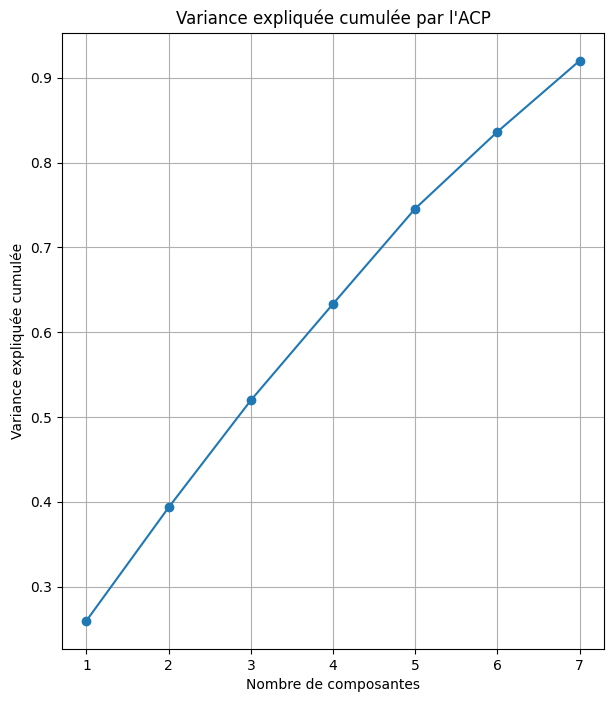

In [23]:
plt.figure(figsize=(7,8))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")
plt.title("Variance expliquée cumulée par l'ACP")
plt.grid(True)
plt.show()

#### Conclusion

- La **réduction de dimension fonctionne** : ton ACP conserve presque toute l’information tout en réduisant le nombre de variables.  
- On passe de **8 colonnes originales à 7 composantes principales**, ce qui simplifie le modèle sans trop perdre de variance.  
- Cela peut **réduire le bruit** dans les données et **améliorer la stabilité et la vitesse** de l’entraînement du modèle.  
- Pour atteindre les **90 % de variance expliquée**, ces 7 composantes suffisent, ce qui correspond parfaitement à ton paramètre `PCA(n_components=0.9)`.

## 8️⃣ Comparaison avec un modèle sans ACP

In [24]:


pipeline_no_pca = Pipeline([
    ('preprocessor', preprocessor),  # ton ColumnTransformer déjà défini
    ('classifier', LogisticRegression(random_state=123, max_iter=1000))
])
pipeline_no_pca.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [25]:

y_pred_no_pca = pipeline_no_pca.predict(X_test)
print(classification_report(y_test, y_pred_no_pca))

              precision    recall  f1-score   support

           0       0.73      0.90      0.80       100
           1       0.66      0.36      0.46        53

    accuracy                           0.71       153
   macro avg       0.69      0.63      0.63       153
weighted avg       0.70      0.71      0.69       153



Interprétation générale

L’ACP réduit la dimensionnalité, ce qui peut aider à diminuer le bruit et à accélérer l’entraînement, mais dans ce cas, elle détériore la capacité à détecter les cas malades (classe 1).

Le modèle sans ACP est meilleur pour la prédiction de la classe minoritaire, ce qui est critique en santé, car détecter les patients à risque est prioritaire.

Pour ce projet, le modèle sans ACP semble préférable si l’objectif principal est de détecter correctement les maladies cardiaques.

## 9️⃣ Modèle KNN avec SMOTE

In [26]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier

pipeline_knn = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=123)),
    ('pca', PCA(n_components=0.9)),
    ('knn', KNeighborsClassifier())
])


Optimiser n_neighbors avec GridSearchCV

In [41]:
from sklearn.model_selection import GridSearchCV

param_grid = {'knn__n_neighbors': [3, 5, 7, 9, 11,13]
              }
grid_knn = GridSearchCV(pipeline_knn, param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_knn.fit(X_train, y_train)

print("Meilleur nombre de voisins :", grid_knn.best_params_)
y_pred_knn = grid_knn.predict(X_test)
print(classification_report(y_test, y_pred_knn))


Meilleur nombre de voisins : {'knn__n_neighbors': 11}
              precision    recall  f1-score   support

           0       0.81      0.71      0.76       100
           1       0.55      0.68      0.61        53

    accuracy                           0.70       153
   macro avg       0.68      0.69      0.68       153
weighted avg       0.72      0.70      0.71       153



 Comparer les performances du meilleur modèle KNN avec celles obtenues par la 
régression logistique. 

Le KNN optimisé, grâce à SMOTE et à l’ACP, détecte mieux la classe des patients malades que la régression logistique. Ainsi, même si sa précision globale est légèrement inférieure, il est plus efficace pour identifier les patients à risque, ce qui est crucial en contexte médical.

### **10️⃣ Entraînement final et sauvegarde**

In [42]:
# Si tu utilises GridSearchCV
best_knn = grid_knn.best_estimator_  # récupère le meilleur pipeline KNN
best_knn.fit(X, y)  # entraînement final sur toutes les données


,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The

Sauvegarder le modèle

In [ ]:
import joblib

joblib.dump(best_knn, 'Model2.pkl')
print("Modèle KNN final sauvegardé sous 'Model2.pkl'")


Modèle KNN final sauvegardé sous 'Model2.pkl'


### **11️⃣ Développement d’une mini-application Streamlit**

Objectif :

 - Charger le modèle sauvegardé.

 - Afficher une interface pour saisir les valeurs des variables.

 - Faire une prédiction et afficher la probabilité.

In [30]:
print(X.columns.tolist())


['sbp', 'tobacco', 'ldl', 'adiposity', 'famhist', 'typea', 'obesity', 'alcohol', 'age']


In [31]:
import sklearn
print(f"scikit-learn version: {sklearn.__version__}")

scikit-learn version: 1.8.0
